<a href="https://colab.research.google.com/github/ifychuky/Credit-Risk-Prediction-End-to-End-ML/blob/main/Credit_Risk_Prediction_End_to_End_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Executive Summary**
#### **Project: Loan Default Prediction**

**Problem:**
Financial institutions face losses when borrowers with high default probability are incorrectly classified as low risk.

The aim of this project is to develop a machine learning pipeline capable of identifying risky loan applicants while providing interpretable insights for decision-making.

**Objective:**
Build an ML system that predicts default risk and identifies borrower segments.


**Goal:** The goal of this project is to help lending institutions identify borrowers with a higher probability of default, enabling improved credit risk management and responsible lending decisions.

**Work Flow:**
1. Raw Data
   ↓
2. SQL Exploration
   ↓
3. EDA
   ↓
4. Cleaning
   ↓
5. Feature Engineering
   ↓
6. Clustering
   ↓
7. Classification Models
   ↓
8. Imbalance Optimization
   ↓
9. Business Recommendation

**Outcome:**
Developed a predictive pipeline for loan risk assessment.

**Dept track:** Imbalance Handling Depth ⭐⭐

**Role:** Team Lead / Machine Learning Contributor

**Responsibilities**:
- Coordinated project development workflow
- Led analytical problem framing
- Designed feature engineering strategy
- Developed and evaluated ML models
- Translated model findings into business recommendations



### Importing Python Libraries

In [1]:
#Importing python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

The loan default dataset was loaded into a pandas DataFrame. This allowed the data to be viewed, cleaned, explored, transformed, and prepared for analysis.

### Importing Loan Dataset from Kaggle

In [2]:
# Download latest version of Dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil1e9/loan-default")

print("Path to dataset files:", path)

100%|██████████| 7.86M/7.86M [00:00<00:00, 68.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nikhil1e9/loan-default/versions/2


### Reading the Dataset

In [3]:
df = pd.read_csv(f"{path}/Loan_default.csv")
df.head(5)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


The dataset contains borrower-related variables such as income, loan amount, credit score, age, loan term, interest rate, and default status.

### Importing SQLite

In [4]:
#importing SQLite
import sqlite3

In [5]:
conn = sqlite3.connect("data.db")

#This steps re-establishes connection to database

In [6]:
df.to_sql(
    'Loan_default',
    conn,
    if_exists='replace',
    index=False
)

#This step loads the .csv data set into data.db. A file readable by sql

255347

The dataset was also saved into an SQLite database to allow basic SQL querying. SQL queries were used to inspect the dataset, view selected records, summarize important variables, and understand the structure of the data from a database perspective.


In [7]:
pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

#This step shows loaded data as table using sqlite_master

,name
0,Loan_default


In [8]:
pd.read_sql_query(
    """select count(*)as no_rows
    FROM Loan_default;""",
    conn
)

,no_rows
0,255347


In [9]:
pd.read_sql_query(
    """SELECT avg(Income) as avg_income
    FROM Loan_default;""",
    conn
)

# Step reveals average income of participants on dataset as avg_income

,avg_income
0,82499.304597


In [10]:
pd.read_sql_query(
    "SELECT * FROM Loan_default LIMIT 10;",
    conn
)

#Shows first 10 rows on dataset using SQL

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
5,A9S62RQ7US,25,90298,90448,720,18,2,22.72,24,0.10,High School,Unemployed,Single,Yes,No,Business,Yes,1
6,H8GXPAOS71,38,111188,177025,429,80,1,19.11,12,0.16,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0
7,0HGZQKJ36W,56,126802,155511,531,67,4,8.15,60,0.43,PhD,Full-time,Married,No,No,Home,Yes,0
8,1R0N3LGNRJ,36,42053,92357,827,83,1,23.94,48,0.20,Bachelor's,Self-employed,Divorced,Yes,No,Education,No,1
9,CM9L1GTT2P,40,132784,228510,480,114,4,9.09,48,0.33,High School,Self-employed,Married,Yes,No,Other,Yes,0


In [11]:
pd.read_sql_query(
    """SELECT LoanID, Age, Income, LoanTerm, CreditScore, LoanAmount
     FROM Loan_default
     ORDER BY LoanAmount DESC
     LIMIT 10;""",
    conn
)

#Table reveals top 10 borrowers and their respective incomes, credit scores and age.


,LoanID,Age,Income,LoanTerm,CreditScore,LoanAmount
0,BZ6O5YSSA8,37,114264,36,598,249999
1,TGYZ4AXW7H,52,140430,24,484,249998
2,VIS6H9YBJM,44,76674,48,304,249997
3,7OV9HHSV62,26,137747,36,451,249996
4,RXGEJP7QPL,65,23329,12,684,249993
5,INBGJEMBW3,54,145587,24,332,249993
6,T81D0AKB24,64,66167,12,794,249992
7,TE1MRP009B,37,136184,48,675,249990
8,PVLUX5GH5X,18,20288,60,302,249989
9,OFQMCX2Z37,39,40994,12,827,249988


In [12]:
pd.read_sql_query(
    """
    SELECT LoanID, Age, Income, LoanTerm, CreditScore, LoanAmount
    FROM Loan_default
    ORDER BY LoanAmount ASC
    LIMIT 10;
    """,
    conn
)

#This shows the bottom 10 Customers that borrowed the least amount, their age, income and credit score

,LoanID,Age,Income,LoanTerm,CreditScore,LoanAmount
0,9AO69WP1G5,38,99437,12,538,5000
1,4PPBDEB2NT,36,106933,24,656,5001
2,ZQZVEVADK0,60,44841,24,755,5005
3,9BPM8OCKIM,65,42520,60,665,5006
4,54JY616FTL,63,84890,24,338,5009
5,U3TAF4CCOP,22,131698,12,494,5009
6,AK2BA4VS3Z,18,64383,36,581,5012
7,DBD6TL0CEU,34,148409,24,672,5012
8,FX3HTQ9W5Y,38,142379,24,305,5012
9,ZSPTPDOJ6U,19,114734,24,820,5015


In [13]:
pd.read_sql_query(
    "SELECT DISTINCT Education FROM Loan_Default;",
    conn
)

#This table shows all the distinct education levels of our customers

,Education
0,Bachelor's
1,Master's
2,High School
3,PhD


**Exploratory Data Analysis**

Exploratory Data Analysis was carried out to understand the structure and quality of the dataset. This included checking the number of rows and columns, viewing column names, examining data types, checking summary statistics, identifying missing values, and checking for duplicated records.


In [14]:
df = pd.read_csv(path + '/Loan_default.csv')
df.head(5)

#Showing first 5 Rows of Dataset

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [15]:
#Overview of Dataset

print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 

In [16]:
# Statistical Summary of Data

print("Statistical Summary:")
print(df.describe())

Statistical Summary:
                 Age         Income     LoanAmount    CreditScore  \
count  255347.000000  255347.000000  255347.000000  255347.000000   
mean       43.498306   82499.304597  127578.865512     574.264346   
std        14.990258   38963.013729   70840.706142     158.903867   
min        18.000000   15000.000000    5000.000000     300.000000   
25%        31.000000   48825.500000   66156.000000     437.000000   
50%        43.000000   82466.000000  127556.000000     574.000000   
75%        56.000000  116219.000000  188985.000000     712.000000   
max        69.000000  149999.000000  249999.000000     849.000000   

       MonthsEmployed  NumCreditLines   InterestRate       LoanTerm  \
count   255347.000000   255347.000000  255347.000000  255347.000000   
mean        59.541976        2.501036      13.492773      36.025894   
std         34.643376        1.117018       6.636443      16.969330   
min          0.000000        1.000000       2.000000      12.000000   
25

In [17]:
#Describing all columns including non-numeric

print(f"Summary of all columns:\n{df.columns}")

Summary of all columns:
Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')


In [18]:
# Showing the number of rows and columns, column names and dimension of data

print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns:{df.shape[1]}')
print(f'\nColumn names: {df.columns}')
print(f'\nDimensions:{df.ndim}')

Number of rows: 255347
Number of columns:18

Column names: Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

Dimensions:2


The dataset was checked for missing values and duplicated observations. This step was necessary to ensure that the data was clean and reliable before further analysis. The results helped confirm whether any cleaning action was required before modeling.


In [19]:
# Checking for missing values

print("Missing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage missing: {df.isnull().sum().sum() / df.size * 100:.2f}%")

Missing values per column:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

Total missing values: 0
Percentage missing: 0.00%


In [20]:
# Checking for duplicated rows
df.duplicated().sum()

np.int64(0)

In [21]:
# Display unique values for categorical columns
df.select_dtypes(include='object').nunique()

,0
LoanID,255347
Education,4
EmploymentType,4
MaritalStatus,3
HasMortgage,2
HasDependents,2
LoanPurpose,5
HasCoSigner,2


In [22]:
#We observed no missing values in our datasets because data has been pre-cleaned by Kaggle
#We also observed that all the columns are well matched, therefore, we won't be converting any of the columns

**Visualisation of Data Sets**

Data visualization was carried out to better understand the distribution of key variables. Visual tools such as histograms, count plots, and correlation heatmaps were used to identify patterns, relationships, and possible differences between defaulters and non-defaulters.



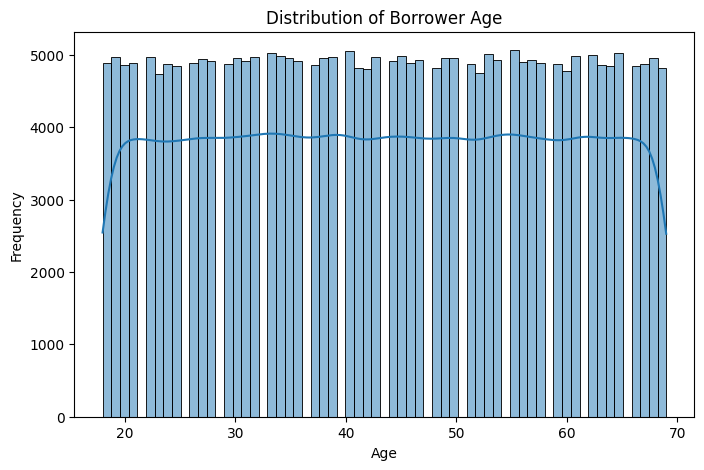

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing the distribution of borrower ages to understandthe demographic spread of customers in the dataset.

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], kde=True)

plt.title('Distribution of Borrower Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

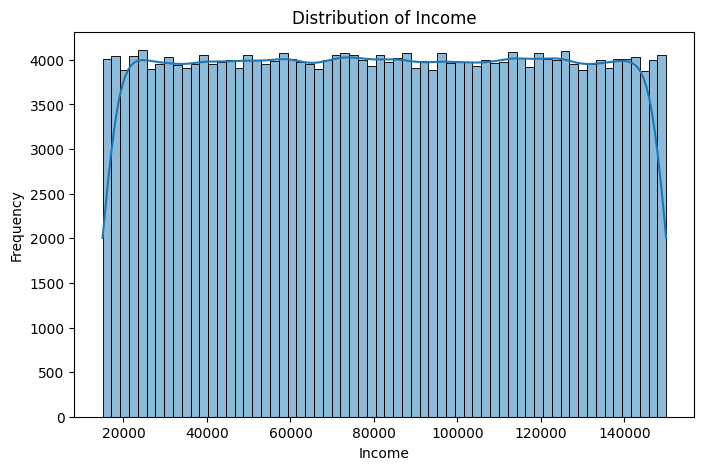

In [24]:
# Visualizing borrower income distribution to examine repayment capacity and identify possible income outliers.
# Income is an important financial indicator in loan risk analysis.

plt.figure(figsize=(8,5))

sns.histplot(df['Income'], kde=True)

plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')

plt.show()

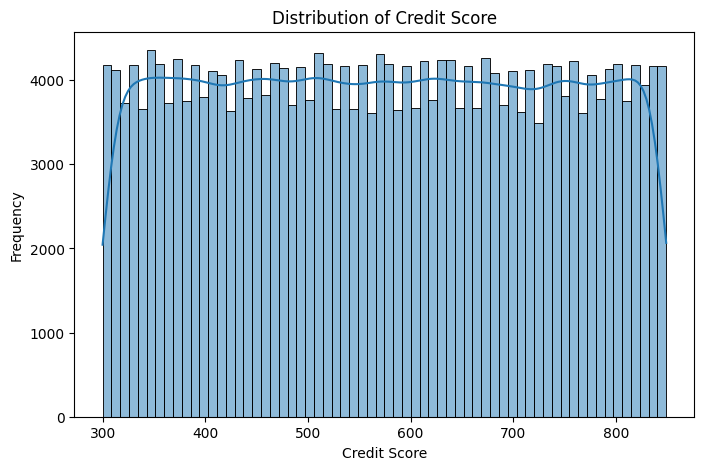

In [25]:
# Visualizing the distribution of credit scores to assess borrower creditworthiness across the dataset.
# Credit score is a major indicator of repayment reliability.

plt.figure(figsize=(8,5))

sns.histplot(df['CreditScore'], kde=True)

plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')

plt.show()

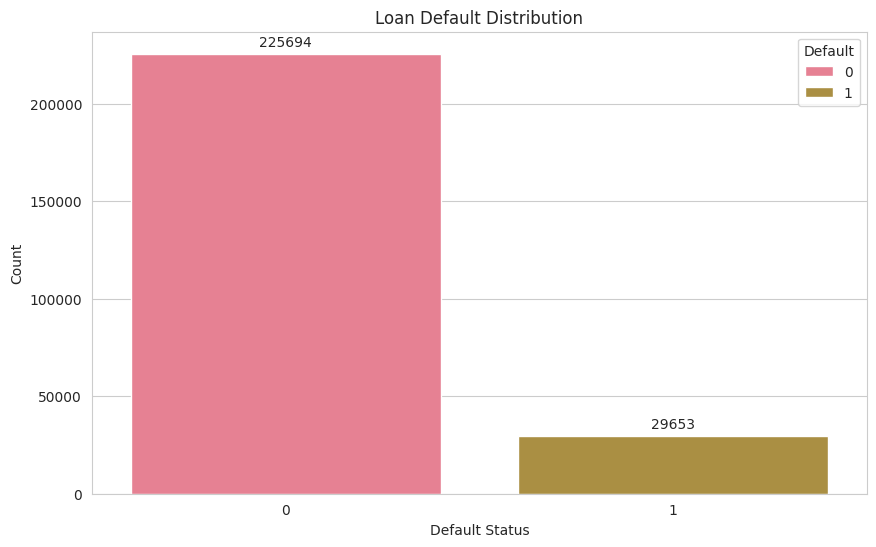

In [26]:
sns.set_style("whitegrid")
sns.set_palette("husl")

plt.figure(figsize=(10, 6))

# Visualizing the distribution of loan default cases to examine class imbalance in the target variable.
ax = sns.countplot(data=df, x="Default", hue="Default")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Loan Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Count")

plt.legend(title="Default")
plt.show()

**Target Variable Distribution**

The distribution of the target variable, `Default`, was examined to understand the balance between borrowers who defaulted and those who did not. The result showed that the dataset was imbalanced, with a much smaller percentage of borrowers belonging to the default class.



In [27]:
print(f"Percentage of Defaulters: \n\n{df["Default"].value_counts(normalize=True)*100}")

Percentage of Defaulters: 

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


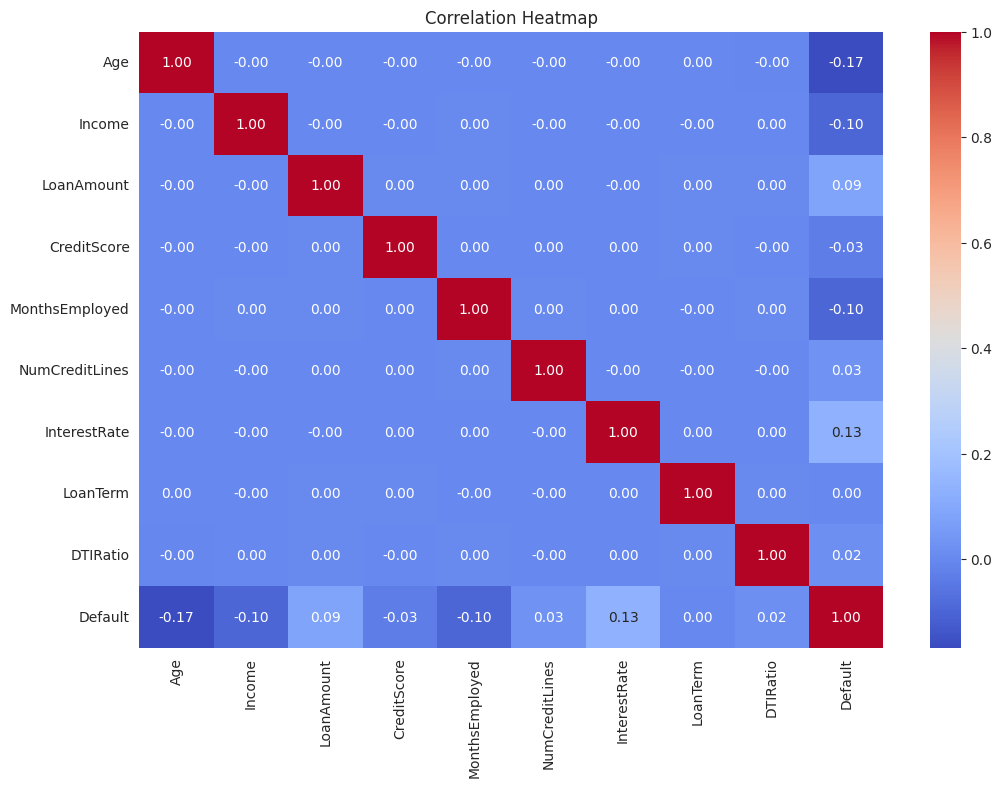

In [28]:
plt.figure(figsize=(12,8))

# Visualizing correlations between numerical variables to identify relationships and potential predictive patterns.
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

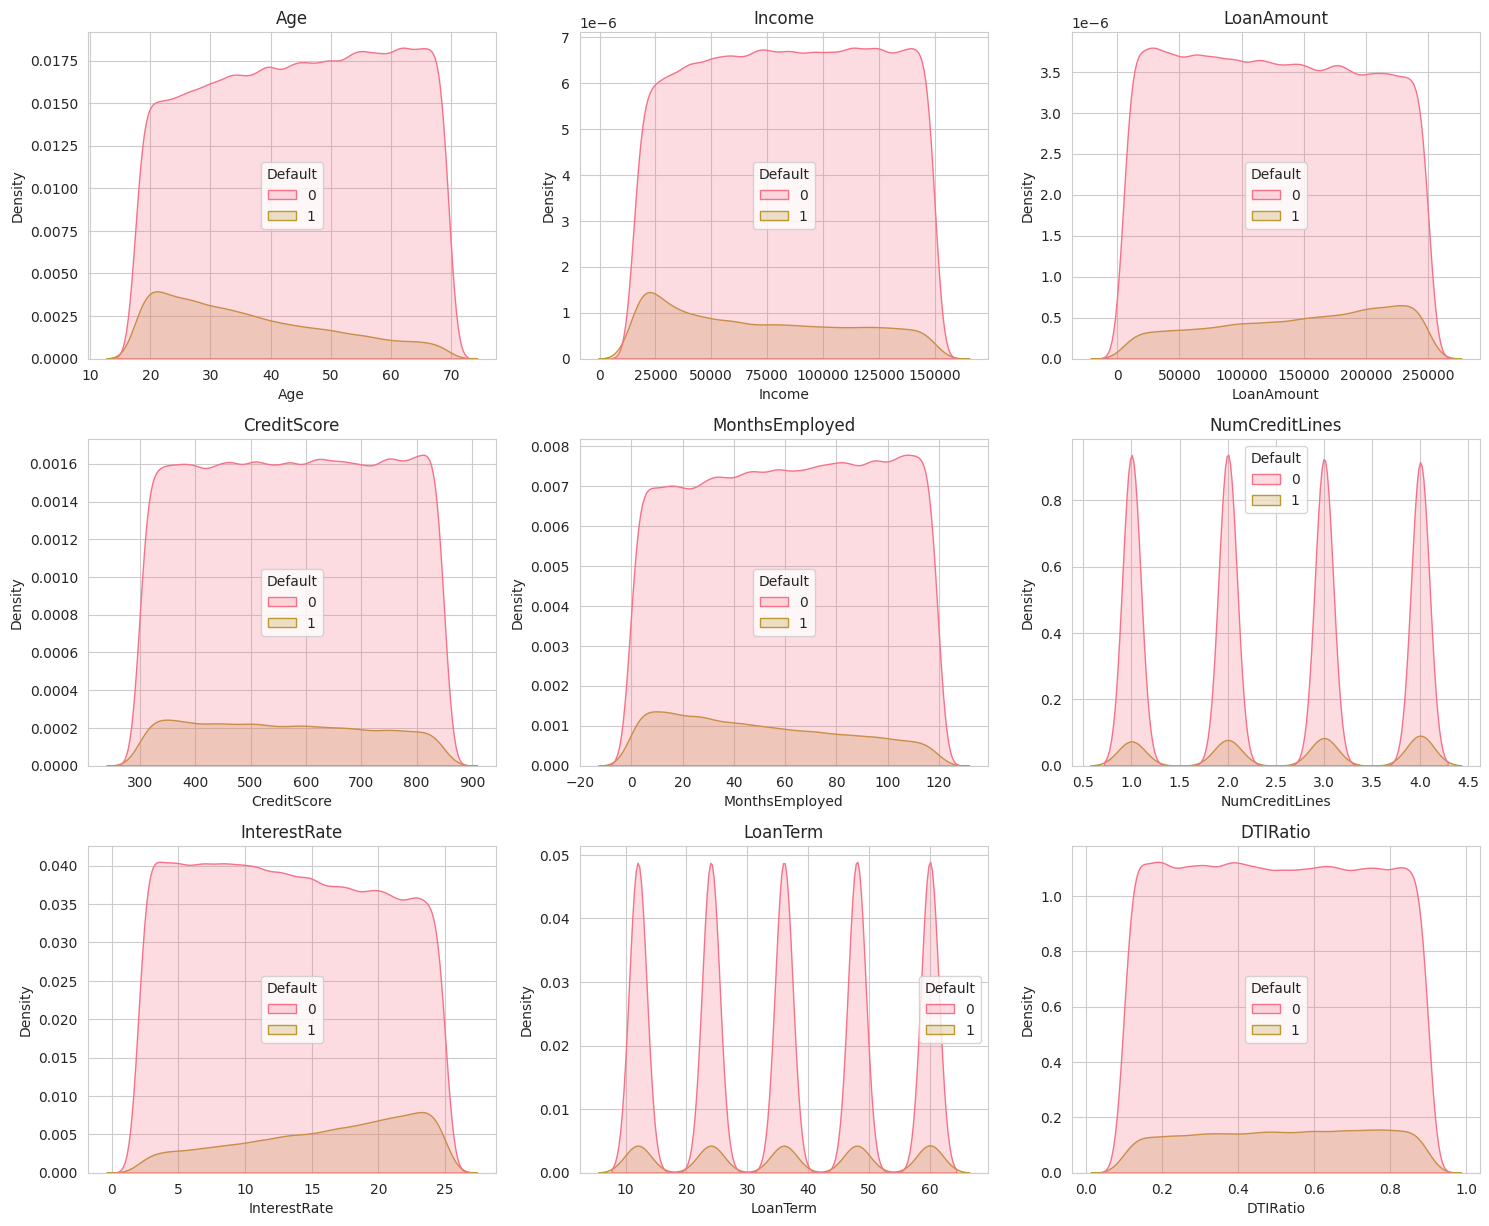

In [29]:
# Let's check the distribution of each numerical feature across loan default categories.

feats = df.drop("Default", axis=1).select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(
    nrows=len(feats)//3 + 1,
    ncols=3,
    figsize=(15, 4 * (len(feats)//3 + 1))
)

axes = axes.flatten()

for i, col in enumerate(feats):
    sns.kdeplot(data=df, x=col, hue="Default", ax=axes[i], fill=True)
    axes[i].set_title(col)

# Hide any leftover empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Part 2: Feature Engineering and Encoding

The purpose of this section is to create meaningful features that improve borrower segmentation, enhance model learning, and increase interpretability of financial risk patterns.

Credit Score Categorization

A new feature called `credit_score_group` was created to classify borrowers into standardized credit risk categories commonly used in financial institutions.


In [30]:
df['credit_score_group'] = pd.cut(
    df['CreditScore'],
    bins=[0, 580, 670, 740, 850],
    labels=['Poor', 'Fair', 'Good', 'Excellent']
)
print('Credit Score Categories:')
print(df['credit_score_group'].value_counts())

Credit Score Categories:
credit_score_group
Poor         130708
Excellent     50771
Fair          41877
Good          31991
Name: count, dtype: int64


Income Group Categorization

A new feature called `income_group` was created to group borrowers into income categories in order to improve interpretability and borrower segmentation.


In [31]:
df['income_group'] = pd.cut(
    df['Income'],
    bins=[0, 30000, 70000, 150000],
    labels=['Low', 'Middle', 'High']
)

print('Income Group Categories:')
print(df['income_group'].value_counts())

Income Group Categories:
income_group
High      151502
Middle     75440
Low        28405
Name: count, dtype: int64


Loan Burden Categorization

A new feature called `loan_burden` was engineered from the existing DTI ratio to classify borrowers according to their level of financial burden.


In [32]:
df['loan_burden'] = pd.cut(
    df['DTIRatio'],
    bins=[0, 0.2, 0.4, 0.6, 1],
    labels=['Low', 'Moderate', 'High', 'Severe']
)

print('Loan Burden Categories:')
print(df['loan_burden'].value_counts())

Loan Burden Categories:
loan_burden
Severe      94334
Moderate    63856
High        63644
Low         33513
Name: count, dtype: int64


Age Group Categorization

A new feature called `age_group` was created to classify borrowers into life-stage categories that may influence repayment behavior and financial stability.


In [33]:
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young', 'Adult', 'Middle_Aged', 'Senior']
)

print('Age Group Categories:')
print(df['age_group'].value_counts())

Age Group Categories:
age_group
Adult          74067
Middle_Aged    73501
Young          63577
Senior         44202
Name: count, dtype: int64


Loan Term Categorization

A new feature called `loan_term_group` was created to categorize loan durations into repayment period groups for improved borrower risk interpretation.


In [34]:
df['loan_term_group'] = pd.cut(
    df['LoanTerm'],
    bins=[0, 12, 36, 60],
    labels=['Short', 'Medium', 'Long']
)

print('Loan Term Categories:')
print(df['loan_term_group'].value_counts())

Loan Term Categories:
loan_term_group
Long      102320
Medium    102070
Short      50957
Name: count, dtype: int64


In [35]:
#To confirm that new meaningful groups have been created

df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,credit_score_group,income_group,loan_burden,age_group,loan_term_group
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,...,Yes,Yes,Other,Yes,0,Poor,High,High,Middle_Aged,Medium
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,...,No,No,Other,Yes,0,Poor,Middle,Severe,Senior,Long
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,...,Yes,Yes,Auto,No,1,Poor,High,Moderate,Middle_Aged,Medium
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,...,No,No,Business,No,0,Excellent,Middle,Moderate,Adult,Medium
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,...,No,Yes,Auto,No,0,Fair,Low,Severe,Middle_Aged,Long


Loan-to-Income Ratio

A new feature called `loan_to_income_ratio` was created to measure the size of the loan relative to borrower income.

While the existing DTI ratio measures the borrower’s overall debt burden, this feature specifically captures the affordability of the current loan itself.

Higher loan-to-income ratios may indicate increased repayment pressure and a greater likelihood of loan default.


In [36]:
df['loan_to_income_ratio'] = df['LoanAmount'] / df['Income']

print('Loan-to-Income Ratio:')
print(df['loan_to_income_ratio'].head())

Loan-to-Income Ratio:
0    0.588262
1    2.467481
2    1.534154
3    1.412638
4    0.447179
Name: loan_to_income_ratio, dtype: float64


DTI and Credit Score Interaction Term

A new interaction feature called `dti_credit_interaction` was created to capture the combined effect of borrower debt burden and creditworthiness on loan default risk.

Borrowers with high debt burdens and poor credit scores may be more likely to default compared to borrowers with lower debt obligations and stronger credit profiles.


In [37]:
df['dti_credit_interaction'] = (
    df['DTIRatio'] * df['CreditScore']
)

print('DTI-Credit Interaction:')
print(df['dti_credit_interaction'].head())

DTI-Credit Interaction:
0    228.80
1    311.44
2    139.81
3    170.89
4    462.09
Name: dti_credit_interaction, dtype: float64


**Encoding Variables**

In [38]:
# Identifying categorical columns in the dataset to determine which variables require encoding.

df.select_dtypes(include=['object', 'category']).columns

Index(['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner', 'credit_score_group',
       'income_group', 'loan_burden', 'age_group', 'loan_term_group'],
      dtype='object')

In [39]:
# Dropping LoanID because it is a unique identifier
# and does not contribute meaningful predictive information.

df.drop('LoanID', axis=1, inplace=True)

Label Encoding Credit Score Categories

Label encoding was applied to `credit_score_group` because the categories possess a natural ranking order from poor creditworthiness to excellent creditworthiness.


In [40]:
credit_score_map = {
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Excellent': 4
}

df['credit_score_group'] = (
    df['credit_score_group']
    .map(credit_score_map)
)

print(df['credit_score_group'].head())

0    1
1    1
2    1
3    4
4    2
Name: credit_score_group, dtype: category
Categories (4, int64): [1 < 2 < 3 < 4]


In [41]:
### Label Encoding Income Groups

# Label encoding was applied to `income_group` because the categories follow a natural income hierarchy from low-income to high-income borrowers.

income_group_map = {
    'Low': 1,
    'Middle': 2,
    'High': 3
}

df['income_group'] = (
    df['income_group']
    .map(income_group_map)
)

print(df['income_group'].head())

0    3
1    2
2    3
3    2
4    1
Name: income_group, dtype: category
Categories (3, int64): [1 < 2 < 3]


Label Encoding Loan Burden Categories

Label encoding was applied to `loan_burden` because the categories represent increasing levels of borrower financial burden.


In [42]:
loan_burden_map = {
    'Low': 1,
    'Moderate': 2,
    'High': 3,
    'Severe': 4
}

df['loan_burden'] = (
    df['loan_burden']
    .map(loan_burden_map)
)

print(df['loan_burden'].head())

0    3
1    4
2    2
3    2
4    4
Name: loan_burden, dtype: category
Categories (4, int64): [1 < 2 < 3 < 4]


Label Encoding Age Groups

Label encoding was applied to `age_group` because the categories follow a natural progression across borrower life stages.


In [43]:
age_group_map = {
    'Young': 1,
    'Adult': 2,
    'Middle_Aged': 3,
    'Senior': 4
}

df['age_group'] = (
    df['age_group']
    .map(age_group_map)
)

print(df['age_group'].head())

0    3
1    4
2    3
3    2
4    3
Name: age_group, dtype: category
Categories (4, int64): [1 < 2 < 3 < 4]


Label Encoding Loan Term Groups

Label encoding was applied to `loan_term_group` because the categories represent increasing loan durations.


In [44]:
loan_term_map = {
    'Short': 1,
    'Medium': 2,
    'Long': 3
}

df['loan_term_group'] = (
    df['loan_term_group']
    .map(loan_term_map)
)

print(df['loan_term_group'].head())

0    2
1    3
2    2
3    2
4    3
Name: loan_term_group, dtype: category
Categories (3, int64): [1 < 2 < 3]


Label Encoding Education Levels

Label encoding was applied to `Education` because educational qualifications follow a natural academic hierarchy from lower to higher academic attainment.


In [45]:
education_map = {
    'High School': 1,
    "Bachelor's": 2,
    "Master's": 3,
    'PhD': 4
}

df['Education'] = df['Education'].map(education_map)

print(df['Education'].head())

0    2
1    3
2    3
3    1
4    2
Name: Education, dtype: int64


In [46]:
# Rechecking categorical columns after label encoding to identify remaining nominal variables.

df.select_dtypes(include=['object', 'category']).columns

Index(['EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'credit_score_group', 'income_group',
       'loan_burden', 'age_group', 'loan_term_group'],
      dtype='object')

In [47]:
#Checked for Binary variables

print(df['HasMortgage'].unique())
print(df['HasDependents'].unique())
print(df['HasCoSigner'].unique())

['Yes' 'No']
['Yes' 'No']
['Yes' 'No']


In [48]:
pd.set_option('display.max_columns', None)

df.head(20)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,credit_score_group,income_group,loan_burden,age_group,loan_term_group,loan_to_income_ratio,dti_credit_interaction
0,56,85994,50587,520,80,4,15.23,36,0.44,2,Full-time,Divorced,Yes,Yes,Other,Yes,0,1,3,3,3,2,0.588262,228.80
1,69,50432,124440,458,15,1,4.81,60,0.68,3,Full-time,Married,No,No,Other,Yes,0,1,2,4,4,3,2.467481,311.44
2,46,84208,129188,451,26,3,21.17,24,0.31,3,Unemployed,Divorced,Yes,Yes,Auto,No,1,1,3,2,3,2,1.534154,139.81
3,32,31713,44799,743,0,3,7.07,24,0.23,1,Full-time,Married,No,No,Business,No,0,4,2,2,2,2,1.412638,170.89
4,60,20437,9139,633,8,4,6.51,48,0.73,2,Unemployed,Divorced,No,Yes,Auto,No,0,2,1,4,3,3,0.447179,462.09
5,25,90298,90448,720,18,2,22.72,24,0.10,1,Unemployed,Single,Yes,No,Business,Yes,1,3,3,1,1,2,1.001661,72.00
6,38,111188,177025,429,80,1,19.11,12,0.16,2,Unemployed,Single,Yes,No,Home,Yes,0,1,3,1,2,1,1.592123,68.64
7,56,126802,155511,531,67,4,8.15,60,0.43,4,Full-time,Married,No,No,Home,Yes,0,1,3,3,3,3,1.226408,228.33
8,36,42053,92357,827,83,1,23.94,48,0.20,2,Self-employed,Divorced,Yes,No,Education,No,1,4,2,1,2,3,2.196205,165.40
9,40,132784,228510,480,114,4,9.09,48,0.33,1,Self-employed,Married,Yes,No,Other,Yes,0,1,3,2,2,3,1.720915,158.40


One-Hot Encoding Nominal Variables

One-hot encoding was applied to nominal categorical variables because the categories do not possess a natural ranking order.
Using label encoding could incorrectly imply ordinal relationships.


In [49]:
df = pd.get_dummies(
    df,
    columns=[
        'EmploymentType',
        'MaritalStatus',
        'LoanPurpose'
    ],
    drop_first=True
)

df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,HasMortgage,HasDependents,HasCoSigner,Default,credit_score_group,income_group,loan_burden,age_group,loan_term_group,loan_to_income_ratio,dti_credit_interaction,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,2,Yes,Yes,Yes,0,1,3,3,3,2,0.588262,228.80,False,False,False,False,False,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,3,No,No,Yes,0,1,2,4,4,3,2.467481,311.44,False,False,False,True,False,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,3,Yes,Yes,No,1,1,3,2,3,2,1.534154,139.81,False,False,True,False,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,1,No,No,No,0,4,2,2,2,2,1.412638,170.89,False,False,False,True,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,2,No,Yes,No,0,2,1,4,3,3,0.447179,462.09,False,False,True,False,False,False,False,False,False


Label Encoding Binary Variables

Label encoding was applied to binary categorical variables because the columns contain only two possible categories:
Yes and No.


In [50]:
binary_map = {
    'No': 0,
    'Yes': 1
}

df['HasMortgage'] = (
    df['HasMortgage']
    .map(binary_map)
)

df['HasDependents'] = (
    df['HasDependents']
    .map(binary_map)
)

df['HasCoSigner'] = (
    df['HasCoSigner']
    .map(binary_map)
)

In [51]:
df.select_dtypes(include=['object', 'category']).columns

Index(['credit_score_group', 'income_group', 'loan_burden', 'age_group',
       'loan_term_group'],
      dtype='object')

In [52]:
#This steps confirms that all encoding has been effected as well as new columns and interaction forms

df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,HasMortgage,HasDependents,HasCoSigner,Default,credit_score_group,income_group,loan_burden,age_group,loan_term_group,loan_to_income_ratio,dti_credit_interaction,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,2,1,1,1,0,1,3,3,3,2,0.588262,228.80,False,False,False,False,False,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,3,0,0,1,0,1,2,4,4,3,2.467481,311.44,False,False,False,True,False,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,3,1,1,0,1,1,3,2,3,2,1.534154,139.81,False,False,True,False,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,0,0,0,4,2,2,2,2,1.412638,170.89,False,False,False,True,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,2,0,1,0,0,2,1,4,3,3,0.447179,462.09,False,False,True,False,False,False,False,False,False


**Feature's Scaling**

Separating Predictor Variables and Target Variable

The predictor variables were separated from the target variable to prepare the dataset for machine learning modeling.


In [53]:
X = df.drop('Default', axis=1)
y = df['Default']

print(X.shape)
print(y.shape)

(255347, 29)
(255347,)


In [54]:
# Importing StandardScaler for feature normalization.

from sklearn.preprocessing import StandardScaler

Initializing the StandardScaler

StandardScaler standardizes feature values by centering them around zero with unit variance.


In [55]:
scaler = StandardScaler()

Applying Feature Scaling

Feature scaling was applied because machine learning algorithms are sensitive to differences in feature magnitude.


In [56]:
X_scaled = scaler.fit_transform(X)

Converting Scaled Features into DataFrame

The scaled feature array was converted back into a dataframe to preserve column names for interpretation.


In [57]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,HasMortgage,HasDependents,HasCoSigner,credit_score_group,income_group,loan_burden,age_group,loan_term_group,loan_to_income_ratio,dti_credit_interaction,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,0.833990,0.089693,-1.086833,-0.341492,0.590533,1.341937,0.261771,-0.001526,-0.260753,-0.444173,0.999973,0.999464,0.999785,-0.844793,0.753738,0.135005,0.591446,-0.268844,-0.729550,-0.367924,-0.579305,-0.576562,-0.577273,-0.708268,-0.706461,-0.501398,-0.499606,-0.501325,2.003812
1,1.701221,-0.823021,-0.044309,-0.731666,-1.285731,-1.343791,-1.308350,1.412793,0.778585,0.450914,-1.000027,-1.000537,0.999785,-0.844793,-0.701572,1.078232,1.553265,1.067691,0.133129,0.152573,-0.579305,-0.576562,-0.577273,1.411895,-0.706461,-0.501398,-0.499606,-0.501325,2.003812
2,0.166888,0.043854,0.022715,-0.775718,-0.968209,0.446694,1.156831,-0.708685,-0.823728,0.450914,0.999973,0.999464,-1.000215,-0.844793,0.753738,-0.808222,0.591446,-0.268844,-0.295327,-0.928414,-0.579305,-0.576562,1.732281,-0.708268,-0.706461,-0.501398,-0.499606,-0.501325,-0.499049
3,-0.767053,-1.303452,-1.168538,1.061875,-1.718715,0.446694,-0.967805,-0.708685,-1.170174,-1.339261,-1.000027,-1.000537,-1.000215,1.661855,-0.701572,-0.808222,-0.370373,-0.268844,-0.351110,-0.732661,-0.579305,-0.576562,-0.577273,1.411895,-0.706461,1.994422,-0.499606,-0.501325,-0.499049
4,1.100830,-1.592855,-1.671921,0.369631,-1.487790,1.341937,-1.052188,0.705634,0.995114,-0.444173,-1.000027,0.999464,-1.000215,-0.009244,-2.156881,1.078232,0.591446,1.067691,-0.794316,1.101420,-0.579305,-0.576562,1.732281,-0.708268,-0.706461,-0.501398,-0.499606,-0.501325,-0.499049


In [58]:
# Displaying summary statistics of scaled features.

X_scaled.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,HasMortgage,HasDependents,HasCoSigner,credit_score_group,income_group,loan_burden,age_group,loan_term_group,loan_to_income_ratio,dti_credit_interaction,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
count,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05,2.553470e+05
mean,-1.808726e-16,3.695367e-17,4.082156e-17,2.277882e-16,9.345549e-17,-4.499206e-17,-6.619937e-16,1.849770e-16,5.248088e-17,1.886223e-16,4.331899e-17,-7.367080e-17,-1.089827e-16,1.042939e-16,2.027165e-16,1.231603e-16,-5.785141e-17,5.619573e-17,2.704045e-16,1.168715e-18,2.626827e-17,-3.205619e-17,2.404214e-17,4.240767e-17,8.459273e-18,-6.661677e-17,-7.791435e-17,-4.263028e-17,7.472821e-17
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-1.700995e+00,-1.732398e+00,-1.730348e+00,-1.725980e+00,-1.718715e+00,-1.343791e+00,-1.731770e+00,-1.415845e+00,-1.733149e+00,-1.339261e+00,-1.000027e+00,-1.000537e+00,-1.000215e+00,-8.447935e-01,-2.156881e+00,-1.751449e+00,-1.332192e+00,-1.605379e+00,-9.841061e-01,-1.620037e+00,-5.793053e-01,-5.765619e-01,-5.772734e-01,-7.082681e-01,-7.064610e-01,-5.013984e-01,-4.996059e-01,-5.013251e-01,-4.990489e-01
25%,-8.337635e-01,-8.642522e-01,-8.670578e-01,-8.638217e-01,-8.527470e-01,-4.485487e-01,-8.623271e-01,-7.086855e-01,-8.670336e-01,-1.339261e+00,-1.000027e+00,-1.000537e+00,-1.000215e+00,-8.447935e-01,-7.015715e-01,-8.082222e-01,-3.703734e-01,-2.688438e-01,-6.306838e-01,-8.113279e-01,-5.793053e-01,-5.765619e-01,-5.772734e-01,-7.082681e-01,-7.064610e-01,-5.013984e-01,-4.996059e-01,-5.013251e-01,-4.990489e-01
50%,-3.324207e-02,-8.547763e-04,-3.227743e-04,-1.663564e-03,1.322113e-02,-4.485487e-01,-4.938420e-03,-1.525943e-03,-9.183609e-04,-4.441732e-01,9.999726e-01,9.994636e-01,9.997846e-01,-8.447935e-01,7.537376e-01,1.350048e-01,-3.703734e-01,-2.688438e-01,-2.895581e-01,-1.468513e-01,-5.793053e-01,-5.765619e-01,-5.772734e-01,-7.082681e-01,-7.064610e-01,-5.013984e-01,-4.996059e-01,-5.013251e-01,-4.990489e-01
75%,8.339895e-01,8.654300e-01,8.668216e-01,8.667877e-01,8.791892e-01,4.466940e-01,8.675186e-01,7.056336e-01,8.651968e-01,4.509141e-01,9.999726e-01,9.994636e-01,9.997846e-01,8.263055e-01,7.537376e-01,1.078232e+00,5.914456e-01,1.067691e+00,2.268981e-01,6.652587e-01,1.726205e+00,-5.765619e-01,-5.772734e-01,1.411895e+00,1.415506e+00,-5.013984e-01,-4.996059e-01,-5.013251e-01,-4.990489e-01
max,1.701221e+00,1.732408e+00,1.728108e+00,1.728946e+00,1.716292e+00,1.341937e+00,1.733948e+00,1.412793e+00,1.731312e+00,1.346001e+00,9.999726e-01,9.994636e-01,9.997846e-01,1.661855e+00,7.537376e-01,1.078232e+00,1.553265e+00,1.067691e+00,6.589832e+00,3.003587e+00,1.726205e+00,1.734419e+00,1.732281e+00,1.411895e+00,1.415506e+00,1.994422e+00,2.001578e+00,1.994714e+00,2.003812e+00


## Part 3: Clustering Analysis

K-Means clustering was applied to identify natural borrower segments within the loan default dataset.

The objectives of the clustering analysis are to:
- identify hidden borrower groups
- analyze borrower financial behavior
- discover risk patterns among customers
- support borrower segmentation analysis

The optimal number of clusters was determined using:
- the elbow method
- silhouette analysis

In [59]:
# Importing clustering and evaluation libraries.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### Elbow Method

The elbow method was used to evaluate the optimal number of clusters by examining the reduction in inertia across different cluster values.


In [60]:
# Creating empty list to store inertia values.

inertias = []

# Defining cluster range for elbow analysis.
k_range = range(1, 11)

# Running K-Means clustering for different K values.
for k in k_range:

    # Initializing K-Means model
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=5
    )

    # Fitting model on full scaled dataset
    km.fit(X_scaled)

    # Storing inertia values
    inertias.append(km.inertia_)

### Elbow Curve Visualization

The elbow curve was plotted to identify the point where increases in cluster numbers resulted in smaller reductions in inertia.

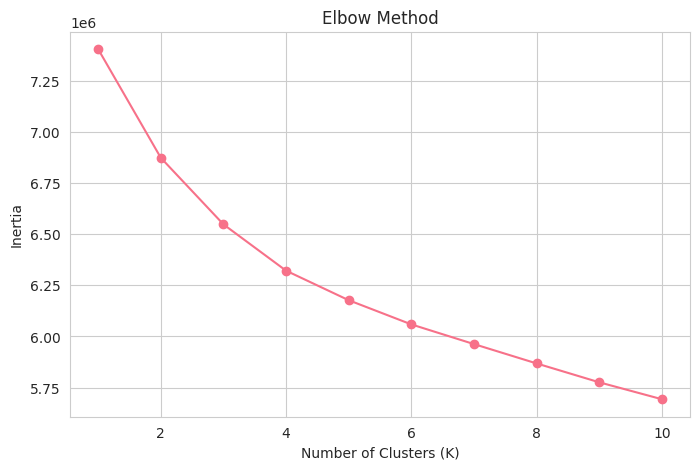

In [61]:
# Plotting elbow curve.

plt.figure(figsize=(8, 5))

plt.plot(
    k_range,
    inertias,
    marker='o'
)

# Setting chart title and labels
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.show()

Using the elbow method, the bend occurs between 2 and 4. K-4 shows the steapest point. We would compare these points using the silhouette score.

The silhouette score tells us how well-separated the clusters are. It ranges from -1 to 1, where higher is better.

### Silhouette Analysis

Silhouette analysis was performed to evaluate cluster cohesion and separation across different cluster values.

Due to the large dataset size and computational complexity of silhouette score calculations, a representative sample consisting of approximately 10% of the scaled dataset was used for silhouette evaluation.

This approach improved runtime efficiency while still preserving the overall structure and distribution of the dataset for reliable cluster assessment.

In [62]:
# Creating sample dataset for silhouette analysis.

X_sample = X_scaled.sample(
    n=25535,
    random_state=42
)

In [63]:
# Creating empty list to store silhouette scores.

silhouette_scores = []

# Defining cluster range for silhouette analysis.
k_range_sil = range(2, 11)

# Running silhouette analysis for different K values.
for k in k_range_sil:

    # Initializing K-Means model
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Generating cluster labels
    labels = km.fit_predict(X_sample)

    # Computing silhouette score
    score = silhouette_score(
        X_sample,
        labels
    )

    # Storing silhouette scores
    silhouette_scores.append(score)

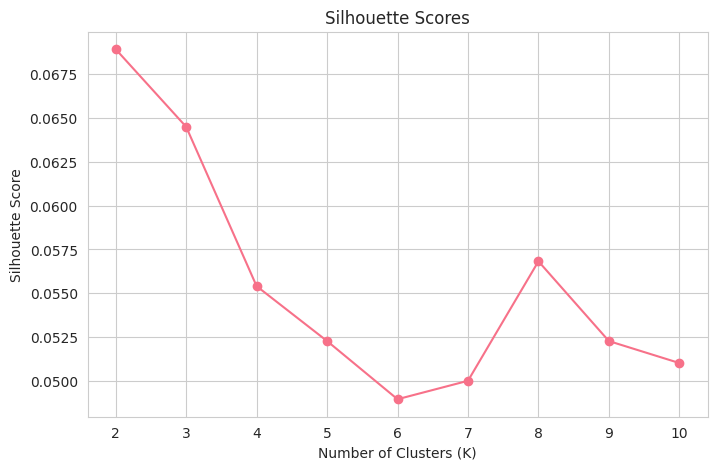

In [64]:
# Plotting silhouette scores.

plt.figure(figsize=(8, 5))

plt.plot(
    k_range_sil,
    silhouette_scores,
    marker='o'
)

# Setting chart title and labels
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.show()

### Selecting the Optimal Number of Clusters

Using the elbow method, the bend in the curve appears between K = 2 and K = 4.

This suggests that cluster values within this range provide the best balance between cluster compactness and model simplicity.

To further validate the optimal number of clusters, silhouette analysis was performed. The silhouette score measures how well-separated and cohesive the clusters are, with values ranging from -1 to 1, where higher values indicate better cluster separation.

The silhouette scores were highest at K = 2 and gradually decreased as the number of clusters increased. However, although K = 2 produced the strongest separation, K = 4 still maintained a reasonable silhouette score while providing more detailed and meaningful borrower segmentation.

Therefore, K = 4 was selected as the optimal number of clusters because it achieved a balance between:
- acceptable cluster separation
- improved borrower segmentation
- better business interpretability

### Training the Final K-Means Model

Based on the elbow curve and silhouette analysis, K = 4 was selected as the optimal number of borrower clusters.

The final K-Means clustering model was then trained using the scaled dataset.

In [65]:
# Training final K-Means clustering model.

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Generating cluster labels
kmeans_labels = kmeans.fit_predict(X_scaled)

### Adding Cluster Labels to Dataset

The generated cluster labels were added to the dataset to support borrower segmentation and cluster profiling.

In [66]:
# Adding cluster labels to dataset.

df["kmeans_cluster"] = kmeans_labels

# Checking cluster distribution
df["kmeans_cluster"].value_counts().sort_index()

,count
kmeans_cluster,
0,45759
1,57693
2,77945
3,73950


### Cluster Profiling

Cluster profiling was performed by examining the average values of key financial variables within each borrower cluster.

This helps identify:
- borrower income patterns
- creditworthiness
- debt burden
- loan exposure
- financial risk characteristics

The results provide business-oriented interpretations for each borrower segment.

In [67]:
# Examining average values of key financial variables within each cluster.

df.groupby("kmeans_cluster").agg({

    "Income": "mean",
    "CreditScore": "mean",
    "DTIRatio": "mean",
    "loan_to_income_ratio": "mean"

}).round(2)

,Income,CreditScore,DTIRatio,loan_to_income_ratio
kmeans_cluster,,,,
0,32303.02,550.36,0.48,5.60
1,88129.90,742.11,0.67,1.62
2,93967.83,569.37,0.25,1.40
3,97079.04,463.27,0.65,1.31


### Cluster Interpretation

#### Cluster 0 — Financially Strained Borrowers
Low-income borrowers with poor credit scores and extremely high repayment pressure.

---

#### Cluster 1 — Strong Credit High-Debt Borrowers
High-income borrowers with excellent credit scores but high debt burden.

---

#### Cluster 2 — Financially Stable Low-Pressure Borrowers
High-income borrowers with poor credit scores but relatively low debt burden and lower repayment pressure.

---

#### Cluster 3 — Credit-Constrained Borrowers
High-income borrowers with very weak credit scores and high debt obligations.

---


### Principal Component Analysis (PCA) Visualization

Principal Component Analysis (PCA) was applied to reduce the high-dimensional dataset into two principal components for visualization purposes.

This allows the borrower clusters generated by K-Means clustering to be visualized in a two-dimensional space while preserving as much variance as possible.

In [68]:
# Importing PCA for dimensionality reduction.

from sklearn.decomposition import PCA

In [69]:
# Reducing dataset into two principal components.

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [70]:
# Creating dataframe for PCA visualization.

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

# Adding cluster labels
pca_df['Cluster'] = kmeans_labels

pca_df.head()

,PC1,PC2,Cluster
0,-0.637889,1.113857,3
1,0.559542,-0.928569,3
2,-1.827045,0.592304,2
3,-0.659213,-0.674288,2
4,1.785446,-1.333203,1


### Visualizing Borrower Clusters

The PCA-transformed dataset was plotted to visualize the distribution and separation of borrower clusters generated by the K-Means algorithm.

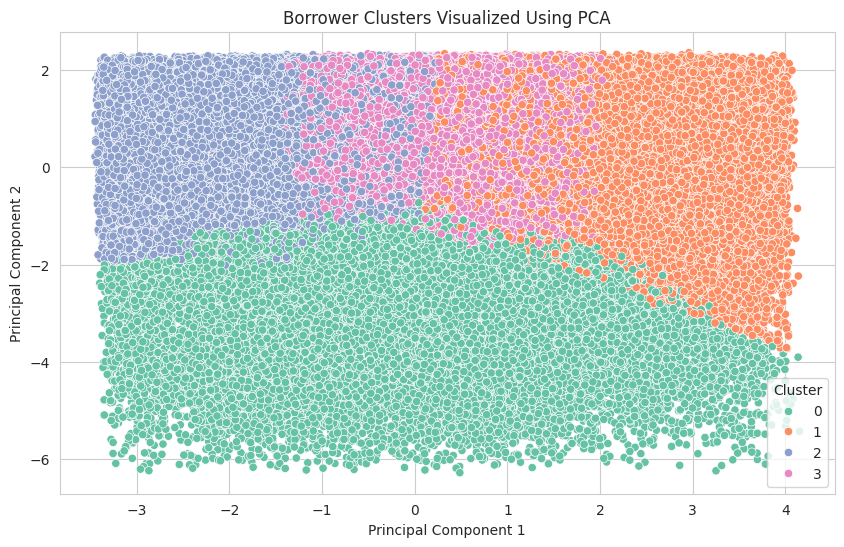

In [71]:
# Visualizing borrower clusters using PCA.

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2'
)

plt.title('Borrower Clusters Visualized Using PCA')

plt.xlabel('Principal Component 1')

plt.ylabel('Principal Component 2')

plt.legend(title='Cluster')

plt.show()

### PCA Visualization Interpretation

The PCA visualization shows meaningful separation between borrower clusters generated by the K-Means algorithm.

Although some overlap exists between clusters, distinct grouping patterns can still be observed across the two principal components. This overlap is expected in real-world financial datasets because borrower characteristics and financial behaviors often share similarities across groups.

The visualization confirms that the clustering model was able to identify different borrower segments based on financial and credit-related features.

## Part 4: Classification

After identifying borrower segments through clustering analysis, the next stage of the project focuses on predictive modeling.

While clustering helped uncover hidden borrower patterns and financial behavior groups, classification models are used to predict whether a borrower is likely to default on a loan.

The objective of this stage is to train machine learning models that can learn from borrower financial characteristics and accurately classify borrowers into:
- default borrowers
- non-default borrowers

This stage transforms the analysis from:
- descriptive analytics
to:
- predictive analytics

and provides practical insights for credit risk assessment and lending decision-making.

The target variable for this stage is:

- 0 = Non-default borrower
- 1 = Default borrower

### Splitting the Dataset

The dataset was divided into training and testing sets to evaluate the ability of the classification models to generalize to unseen borrower data.

The predictor variables were stored in X, while the target variable (Default) was stored in y.

In [72]:
# Importing train-test split function.

from sklearn.model_selection import train_test_split

In [73]:
# Splitting the dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,

    test_size=0.2,
    random_state=42,
    stratify=y

)

# Checking the shape of the datasets.

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(204277, 29)
(51070, 29)
(204277,)
(51070,)


The training dataset was used for model learning, while the testing dataset was used to evaluate model performance on unseen borrower observations.

In [74]:
stratify=y

#Stratification was applied to maintain similar class distribution between default and non-default borrowers across both datasets.

In [75]:
y_train.value_counts(normalize=True).round(3)

,proportion
Default,
0,0.884
1,0.116


In [76]:
y_test.value_counts(normalize=True).round(3)

,proportion
Default,
0,0.884
1,0.116


Stratification ensures that:

- both training and testing sets maintain similar proportions of default and non-default borrowers.

Notably, the default ratio is preserved at about 12% across both sets.  

### Training Classification Models

Multiple machine learning classification models were trained to predict borrower default risk using the processed borrower dataset.

Three classification algorithms were selected and trained to predict borrower default behavior.

The selected models include:
- Logistic Regression
- Decision Tree
- Random Forest

These models were chosen to compare:
- linear classification methods
- rule-based learning methods
- ensemble learning methods

and evaluate their effectiveness in predicting loan default risk.

In [77]:
# Importing classification models.

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

In [78]:
# Scaling the training and testing datasets.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [79]:
# Checking dataset dimensions.

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(204277, 29)
(51070, 29)
(204277,)
(51070,)


### Logistic Regression

Logistic Regression predicts the probability of borrower default by learning relationships between financial variables and repayment behavior. It was selected because it is a widely used baseline classification algorithm for binary prediction problems.

The model predicts the probability of borrower default by learning linear relationships between borrower financial characteristics and repayment behavior.

Logistic Regression is computationally efficient, interpretable, and performs well on structured financial datasets.

Although the name contains “regression,” the algorithm is commonly used for binary classification problems such as predicting:
- 1 - default
- 0 - non-default borrowers

The model attempts to draw a decision boundary between borrowers who are likely to repay loans and borrowers who are likely to default.

In [80]:
# Training Logistic Regression model.

logreg = LogisticRegression(

    max_iter=1000,
    random_state=42

)

logreg.fit(

    X_train_scaled,
    y_train

)

LogisticRegression(max_iter=1000, random_state=42)

In [81]:
# Generating predictions using Logistic Regression.

y_pred_lr = logreg.predict(X_test_scaled)

# Generating prediction probabilities.

y_proba_lr = logreg.predict_proba(
    X_test_scaled
)[:,1]

## Model Classification:

The trained classification models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC score
- Confusion Matrix

These evaluation metrics were used to assess the ability of the models to correctly identify default and non-default borrowers.

In [82]:
# Importing evaluation metrics.

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix

)

In [83]:
# Logistic Regression classification report.

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.61      0.07      0.12      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.53      0.53     51070
weighted avg       0.86      0.89      0.84     51070



In [84]:
# Creating Logistic Regression evaluation metrics.

lr_results = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"

    ],

    "Score": [

        accuracy_score(y_test, y_pred_lr),

        precision_score(y_test, y_pred_lr),

        recall_score(y_test, y_pred_lr),

        f1_score(y_test, y_pred_lr),

        roc_auc_score(y_test, y_proba_lr)

    ]

})

lr_results

,Metric,Score
0,Accuracy,0.886763
1,Precision,0.610778
2,Recall,0.068791
3,F1-Score,0.123655
4,ROC-AUC,0.761605


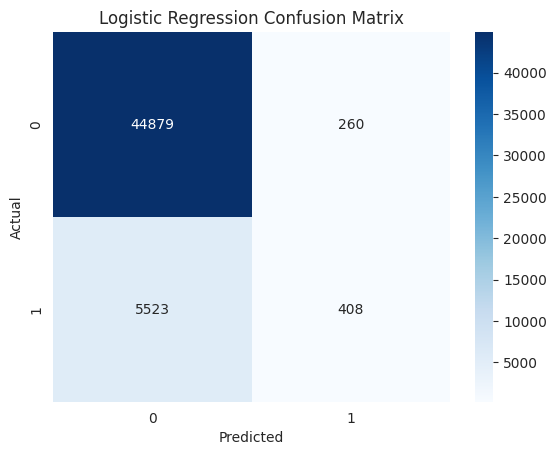

In [85]:
# Plotting Logistic Regression confusion matrix.

sns.heatmap(

    confusion_matrix(
        y_test,
        y_pred_lr
    ),

    annot=True,
    fmt='d',
    cmap='Blues'

)

plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

### Model Outcome Interpretation:

The Logistic Regression model achieved an accuracy score of 89.0%, indicating strong overall borrower classification performance.

The model achieved a precision score of 61.0%, a recall score of 7.0%, and an F1-score of 12.0% for default borrowers. This indicates that although the model was reasonably accurate when predicting borrower default, it identified only a small proportion of actual defaulters.

The model also achieved a weighted average F1-score of 84.0%, reflecting strong classification performance for the majority non-default borrower class. However, the low recall score suggests that class imbalance within the dataset limited the model’s ability to effectively detect default borrowers.

### Decision Tree Classifier

Decision Tree classifies borrowers by creating decision rules based on financial and credit-related variables. It was selected because it can capture non-linear borrower behavior patterns and mimic human decision-making.

The model splits borrowers into different paths using variables such as income, debt burden, and credit score to determine whether a borrower is likely to default or repay a loan.

Decision Trees are interpretable, flexible, and useful for identifying important borrower risk patterns.

In [86]:
# Training Decision Tree model.

dt = DecisionTreeClassifier(

    max_depth=100,
    min_samples_split=20,
    min_samples_leaf=5,
    random_state=42

)

dt.fit(

    X_train,
    y_train

)

#The Decision Tree model was regularized by limiting tree depth and controlling minimum sample requirements for node splitting and leaf creation.
#These constraints help reduce overfitting and improve the model’s ability to generalize to unseen borrower data.

DecisionTreeClassifier(max_depth=100, min_samples_leaf=5, min_samples_split=20,
                       random_state=42)

In [87]:
# Generating Decision Tree predictions.

y_pred_dt = dt.predict(

    X_test

)

# Generating Decision Tree probability predictions.

y_proba_dt = dt.predict_proba(

    X_test

)[:,1]

In [88]:
# Decision Tree classification report.

print(

    classification_report(

        y_test,
        y_pred_dt

    )

)

              precision    recall  f1-score   support

           0       0.90      0.94      0.92     45139
           1       0.27      0.17      0.21      5931

    accuracy                           0.85     51070
   macro avg       0.58      0.56      0.56     51070
weighted avg       0.82      0.85      0.84     51070



In [89]:
# Creating Decision Tree evaluation metrics.

dt_results = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"

    ],

    "Score": [

        accuracy_score(y_test, y_pred_dt),

        precision_score(y_test, y_pred_dt),

        recall_score(y_test, y_pred_dt),

        f1_score(y_test, y_pred_dt),

        roc_auc_score(y_test, y_proba_dt)

    ]

})

dt_results

,Metric,Score
0,Accuracy,0.849892
1,Precision,0.271048
2,Recall,0.173158
3,F1-Score,0.211317
4,ROC-AUC,0.605860


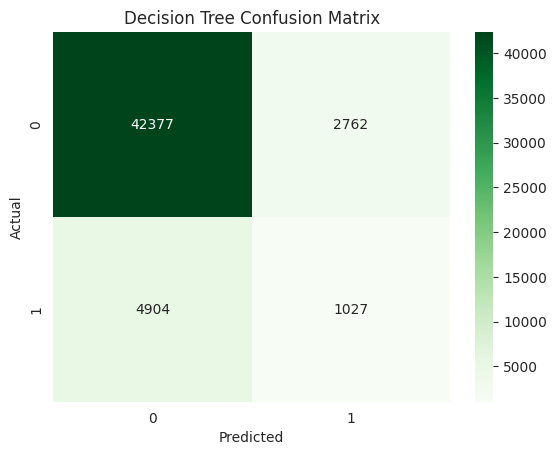

In [90]:
# Plotting Decision Tree confusion matrix.

sns.heatmap(

    confusion_matrix(

        y_test,
        y_pred_dt

    ),

    annot=True,
    fmt='d',
    cmap='Greens'

)

plt.title(
    'Decision Tree Confusion Matrix'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

### Model Outcome Interpretation:

The tuned Decision Tree model achieved an accuracy score of 85.0%, demonstrating strong overall borrower classification performance while improving its ability to detect default borrowers.

The model achieved a precision score of 27.0%, a recall score of 17.0%, and an F1-score of 21.0% for default borrowers, indicating improved minority-class prediction performance compared to earlier model configurations.

The weighted average F1-score of 84.0% further suggests strong classification performance for the majority non-default borrower class. Although the model still struggled with class imbalance, the improved recall and F1-score indicate that the tuned Decision Tree became more effective at identifying risky borrowers and capturing complex borrower default patterns.

In [91]:
dt_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": dt.feature_importances_
}).sort_values("importance", ascending=False).head(10)

dt_importance

,feature,importance
18,loan_to_income_ratio,0.161372
6,InterestRate,0.129584
0,Age,0.108569
4,MonthsEmployed,0.089062
3,CreditScore,0.080589
1,Income,0.076522
2,LoanAmount,0.075700
19,dti_credit_interaction,0.071365
8,DTIRatio,0.052442
5,NumCreditLines,0.021163


### Feature Importance Interpretation:

The Decision Tree model identified loan-to-income ratio as the most important predictor of borrower default behavior, suggesting that repayment burden relative to borrower income strongly influences default risk.

Age, interest rate, and employment duration also demonstrated strong predictive importance, indicating that borrower financial stability and borrowing cost significantly affect repayment outcomes.

### Random Forest Classifier

Random Forest predicts borrower default by combining multiple decision trees instead of relying on a single tree. It was selected because ensemble learning improves prediction stability and reduces overfitting.

The model aggregates predictions from several decision trees to improve classification performance and strengthen borrower risk prediction.

Random Forest performs well on structured financial datasets and is widely used in credit risk prediction problems.

In [92]:
# Training Random Forest model.

rf = RandomForestClassifier(

    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42

)

rf.fit(

    X_train,
    y_train

)

RandomForestClassifier(min_samples_leaf=2, min_samples_split=10,
                       random_state=42)

In [93]:
# Generating Random Forest predictions.

y_pred_rf = rf.predict(

    X_test

)

# Generating Random Forest probability predictions.

y_proba_rf = rf.predict_proba(

    X_test

)[:,1]

In [94]:
# Random Forest classification report.

print(

    classification_report(

        y_test,
        y_pred_rf

    )

)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.05      0.08      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.51     51070
weighted avg       0.86      0.89      0.84     51070



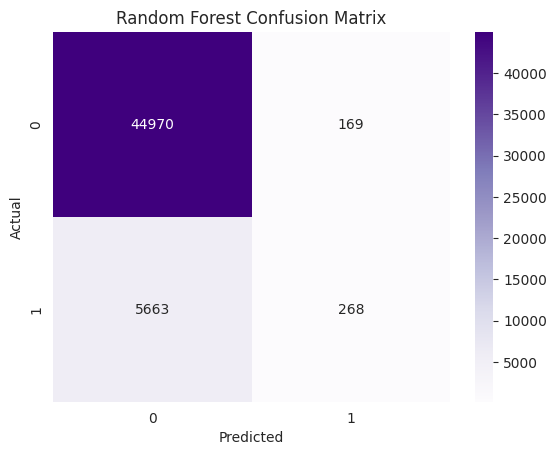

In [95]:
# Plotting Random Forest confusion matrix.

sns.heatmap(

    confusion_matrix(

        y_test,
        y_pred_rf

    ),

    annot=True,
    fmt='d',
    cmap='Purples'

)

plt.title(
    'Random Forest Confusion Matrix'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [96]:
# Creating feature importance dataframe.

rf_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

}).sort_values(

    by="Importance",
    ascending=False

).head(10)

rf_importance

,Feature,Importance
6,InterestRate,0.111795
18,loan_to_income_ratio,0.111790
1,Income,0.088216
4,MonthsEmployed,0.084880
2,LoanAmount,0.082922
0,Age,0.077792
3,CreditScore,0.073803
19,dti_credit_interaction,0.071441
8,DTIRatio,0.059291
16,age_group,0.026739


In [97]:
## Step 16 — Comparing Model Performance

def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

In [98]:
results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr),
    evaluate_model("Decision Tree", y_test, y_pred_dt, y_proba_dt),
    evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf),
])

results.round(3)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.887,0.611,0.069,0.124,0.762
1,Decision Tree,0.850,0.271,0.173,0.211,0.606
2,Random Forest,0.886,0.613,0.045,0.084,0.742


A model’s performance should not be judged using only one metric. Accuracy may appear high because most applicants may not default on their loans. However, a closer look at the recall values for the defaulter class in the classification reports shows that the model fails to correctly identify many applicants who are likely to default. This reflects the effect of class imbalance, which will be addressed in the next stage.


## Part 5: Handling Class Imbalance

Only about 11.6% of borrowers defaulted on their loans, while 88.4% did not. This shows a clear class imbalance in the dataset. With such an uneven distribution, many classification models may learn to predict the majority class, that is, “non-defaulter,” most of the time because doing so can still produce high accuracy. However, this comes at a serious cost: the model may fail to identify many actual defaulters, who are the most important customers for the business to detect.

To address this issue, two common techniques are applied to help the model pay more attention to the minority class and improve its ability to identify likely loan defaulters.

### Approach 1: Class Weight

We set `class_weight='balanced'` and the model automatically weights each class inversely to how often it appears.

In [99]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=10, min_samples_split=20, n_jobs=-1,
                       random_state=42)

In [100]:
y_pred_rf_bal = rf_balanced.predict(X_test)

In [101]:
y_proba_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]

In [102]:
print(classification_report(y_test, y_pred_rf_bal))

              precision    recall  f1-score   support

           0       0.94      0.74      0.82     45139
           1       0.24      0.64      0.35      5931

    accuracy                           0.72     51070
   macro avg       0.59      0.69      0.59     51070
weighted avg       0.86      0.72      0.77     51070



Recall for the **loan defaulter class** usually improves after handling class imbalance. Precision may reduce slightly, and the overall accuracy may also drop, but the model becomes better at identifying borrowers who are likely to default. This is more useful for the business because detecting possible defaulters is the main goal.


### Approach 2: Threshold Tuning

By default, sklearn classifies a borrower as a defaulter when the predicted probability of default is above 0.5. However, this 0.5 threshold is only a default setting and may not be suitable for an imbalanced loan default dataset. We can lower the threshold so that the model identifies more potential defaulters, although this may also increase false alarms by wrongly flagging some non-defaulters as defaulters. The advantage of threshold tuning is that the model does not need to be retrained; we only adjust the probability cut-off used for classification.

In [103]:
thresholds = [0.5, 0.4, 0.3, 0.2]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t),
    })

pd.DataFrame(threshold_results).round(3)

,threshold,precision,recall,f1
0,0.5,0.613,0.045,0.084
1,0.4,0.524,0.108,0.179
2,0.3,0.399,0.237,0.297
3,0.2,0.294,0.459,0.358


Reducing the classification threshold usually improves recall but reduces precision. The precision-recall curve shown below illustrates how precision and recall change at different threshold values.


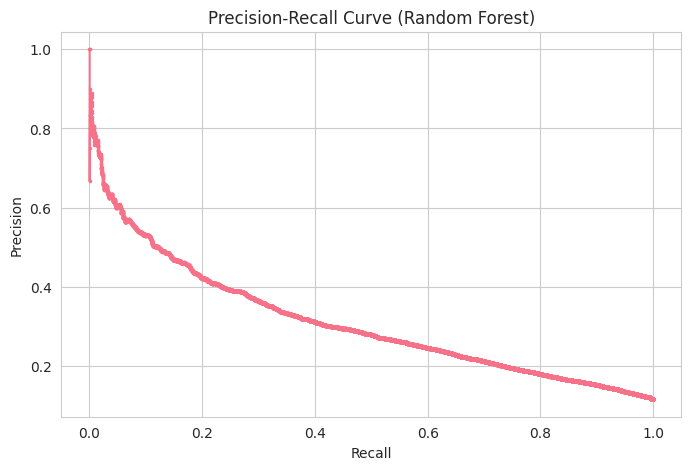

In [104]:
from sklearn.metrics import precision_recall_curve
prec, rec, thr = precision_recall_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 5))
plt.plot(rec, prec, marker=".", markersize=3)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest)")
plt.grid(True)
plt.show()

### Comparing All Three

In [105]:
y_pred_threshold = (y_proba_rf >= 0.3).astype(int)

imbalance_results = pd.DataFrame([
    evaluate_model("Baseline RF", y_test, y_pred_rf, y_proba_rf),
    evaluate_model("RF + class_weight", y_test, y_pred_rf_bal, y_proba_rf_bal),
    evaluate_model("RF + threshold 0.3", y_test, y_pred_threshold, y_proba_rf),
])

imbalance_results.round(3)

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline RF,0.886,0.613,0.045,0.084,0.742
1,RF + class_weight,0.724,0.240,0.638,0.349,0.751
2,RF + threshold 0.3,0.870,0.399,0.237,0.297,0.742


The Baseline Random Forest has the highest accuracy at 0.886, but it performs poorly in detecting actual loan defaulters because its recall is only 0.045 and its F1-score is very low at 0.084. This means the model is mostly predicting the majority class, that is, non-defaulters.

The Random Forest with class weighting performs best overall for the defaulter class. Although its accuracy drops to 0.724, it has the highest recall at 0.638 and the highest F1-score at 0.349. Since F1-score balances precision and recall, this suggests that the class-weighted model gives the best trade-off between correctly identifying defaulters and avoiding too many false alarms.

The Random Forest with threshold 0.3 improves over the baseline, with an F1-score of 0.297, but it is still lower than the class-weighted model. Its recall improves to 0.237, but not as strongly as the class-weighted model.

The **RF + class_weight model is the best-performing option** based on the business goal.


## Part 6: The Tie In

Computing the rate of the positive class within each clusters using the K-means cluster label initially built

In [106]:
default_rate_by_cluster = (
    df.groupby("kmeans_cluster")["Default"]
    .mean()
    .rename("default_rate")
)

default_rate_by_cluster.round(3)

,default_rate
kmeans_cluster,
0,0.205
1,0.097
2,0.090
3,0.104


In [107]:
cluster_default_summary = df.groupby("kmeans_cluster")["Default"].agg(
    total_borrowers="count",
    number_of_defaulters="sum",
    default_rate="mean"
)

cluster_default_summary["default_rate_percent"] = (
    cluster_default_summary["default_rate"] * 100
)

cluster_default_summary.round(3)

,total_borrowers,number_of_defaulters,default_rate,default_rate_percent
kmeans_cluster,,,,
0,45759,9372,0.205,20.481
1,57693,5569,0.097,9.653
2,77945,7015,0.090,9.000
3,73950,7697,0.104,10.408


The K-means clustering result shows that Cluster 0 has the highest loan default risk.

Cluster 0 contains 45,759 borrowers, out of which 9,372 defaulted, giving a default rate of 20.48%. This is much higher than the overall default rate of about 11.6%, so this cluster represents the riskiest group while Clusters 1, 2, and 3 contain relatively lower-risk borrowers.

## Part 7: Conclusion and Recommendations

**Model Deployment Decision**

Based on the results obtained, the Random Forest with class weighting model would be the most suitable model to deploy. Although the baseline Random Forest produced the highest accuracy of 0.886, it performed poorly in identifying actual loan defaulters, with a recall of only 0.045. This means that the model missed most of the borrowers who truly defaulted.

The class-weighted Random Forest is more appropriate because it achieved a much better recall of 0.638 and the highest ROC-AUC value of 0.751. Even though its accuracy reduced to 0.724, it is more useful for the business objective because it detects more risky borrowers. In loan default prediction, identifying potential defaulters is more important than simply achieving high accuracy.

**Improvements with More Time**

With an additional month, the project could be improved through deeper feature engineering and more detailed model tuning. More meaningful borrower-risk variables could be created, such as debt burden indicators, repayment pressure ratios, income stability measures, and stronger credit-risk features.

Additional machine learning models could also be tested and compared. The models could be tuned more carefully using cross-validation and hyperparameter optimization. More attention could also be given to threshold tuning, where the final classification cut-off is selected based on business cost. For example, the cost of approving a borrower who later defaults may be higher than the cost of wrongly flagging a good borrower.

Finally, the model could be tested on fresh or unseen data to confirm that it performs well beyond the current dataset.

**Insights from Clustering**

The clustering analysis revealed that borrowers do not all carry the same level of risk. The K-Means results showed that Cluster 0 had the highest concentration of loan defaulters. This cluster contained 45,759 borrowers, out of which 9,372 defaulted, giving a default rate of 20.48%. This is much higher than the overall default rate of about 11.6%.

This finding shows that clustering added useful business insight beyond the classifier. While the classifier predicts whether a borrower is likely to default, the clusters help identify borrower segments where default is more concentrated. In this case, Cluster 0 represents the riskiest borrower group and may require closer monitoring, stricter approval checks, or special credit-risk policies.

**Hardest Team Decision**

The hardest decision made by the team was choosing between a model with higher accuracy and a model that was better at identifying actual defaulters. The baseline Random Forest appeared better at first because it had the highest accuracy. However, its recall was very low, meaning it failed to detect most borrowers who actually defaulted.

The team therefore had to prioritize business usefulness over surface-level accuracy. This meant accepting the lower accuracy of the class-weighted Random Forest because it captured more actual defaulters. The decision was difficult because lower accuracy can appear less impressive, but in a loan default prediction problem, missing risky borrowers can be more costly than wrongly flagging some low-risk borrowers.

## Personal Reflection

Leading this project strengthened my understanding that machine learning is not only about maximizing accuracy.

The most important decisions involved balancing model performance with real-world business costs, especially reducing missed high-risk borrowers.

This project is a stepping stone as I continue deepening my understanding of machine learning and exploring applications within healthcare datasets, including patient risk prediction and healthcare resource optimization.